In [1]:
# ==================== IMPORTS & DATA PREP ====================
%run CleanData.ipynb

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_curve, auc
)
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

# Reshape for autoencoder (flattened input)
X_train = X_train.values
X_test = X_test.values


In [2]:
# ==================== AUTOENCODER DEFINITION ====================
input_dim = X_train.shape[1]
encoding_dim = 64  # compression size

input_layer = Input(shape=(input_dim,))
encoded = Dense(128, activation='relu')(input_layer)
encoded = Dense(encoding_dim, activation='relu')(encoded)

decoded = Dense(128, activation='relu')(encoded)
decoded = Dense(input_dim, activation='linear')(decoded)

autoencoder = Model(inputs=input_layer, outputs=decoded)
autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
autoencoder.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 133)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        17,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 133)            │        17,157 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,885 (198.77 KB)

 Trainable params: 50,885 (198.77 KB)

 Non-trainable params: 0 (0.00 B)

In [3]:
# ==================== TRAIN AUTOENCODER ====================
# Split training data into training and validation sets
X_train_final, X_val, _, _ = train_test_split(
    X_train, X_train, test_size=0.15, random_state=42
)

# Train autoencoder using only training and validation sets
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = autoencoder.fit(
    X_train_final, X_train_final,
    epochs=50,
    batch_size=64,
    validation_data=(X_val, X_val),
    callbacks=[early_stop],
    verbose=1
)



Epoch 1/50
1318/1318 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0124 - val_loss: 0.0012
Epoch 2/50
1318/1318 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0011 - val_loss: 8.6118e-04
Epoch 3/50
1318/1318 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 7.5700e-04 - val_loss: 6.3723e-04
Epoch 4/50
1318/1318 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 6.4656e-04 - val_loss: 5.6057e-04
Epoch 5/50
1318/1318 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 5.7020e-04 - val_loss: 5.7755e-04
Epoch 6/50
1318/1318 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 5.3914e-04 - val_loss: 5.1054e-04
Epoch 7/50
1318/1318 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 5.0641e-04 - val_loss: 5.1574e-04
Epoch 8/50
1318/1318 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 5.0187e-04 - val_loss: 5.0020e-04
Epoch 9/50
1318/1318 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 4.9209e-04 - val_loss: 5.1005e-04
Epoch 10/50
1318/1318 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 4.7906e-04 - val_loss: 4.5947e-04
Epoch 11/50
1318/1318 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/s

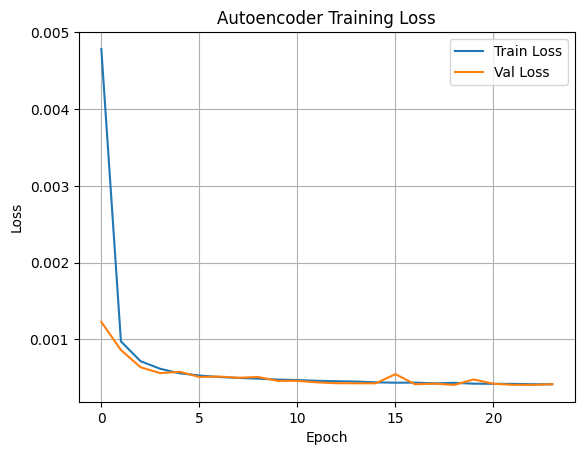

In [4]:
# ==================== PLOT TRAINING HISTORY ====================
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Autoencoder Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


In [5]:
# ==================== COMPUTE RECONSTRUCTION ERRORS ====================
X_test_pred = autoencoder.predict(X_test)
reconstruction_errors = np.mean(np.square(X_test - X_test_pred), axis=1)


776/776 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


In [6]:
# ==================== CONVERT TO BINARY CLASSIFICATION ====================
# Treat anything not class 0 as anomaly
y_true_int = y_test.astype(int)  # already integer-labeled in CleanData
y_true_binary = np.where(y_true_int == 0, 0, 1)

# Define anomaly threshold (e.g. 95th percentile)
threshold = np.percentile(reconstruction_errors, 95)
y_pred_binary = (reconstruction_errors > threshold).astype(int)


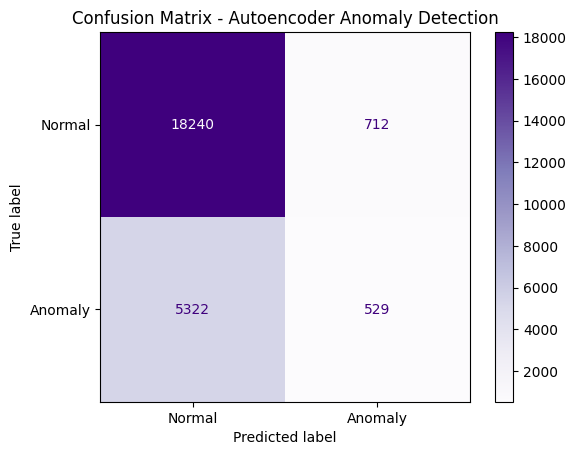

Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.96      0.86     18952
           1       0.43      0.09      0.15      5851

    accuracy                           0.76     24803
   macro avg       0.60      0.53      0.50     24803
weighted avg       0.69      0.76      0.69     24803



In [7]:
# ==================== CONFUSION MATRIX & CLASSIFICATION REPORT ====================
cm = confusion_matrix(y_true_binary, y_pred_binary)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Anomaly"])
disp.plot(cmap="Purples")
plt.title("Confusion Matrix - Autoencoder Anomaly Detection")
plt.show()

print("Classification Report:\n", classification_report(y_true_binary, y_pred_binary))


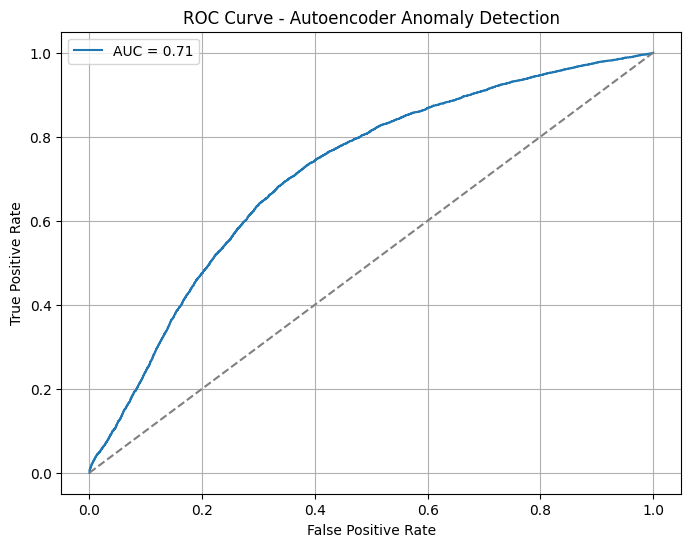

In [8]:
# ==================== ROC & AUC ====================
fpr, tpr, _ = roc_curve(y_true_binary, reconstruction_errors)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Autoencoder Anomaly Detection")
plt.legend()
plt.grid(True)
plt.show()
